In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Churn_modelling.csv')

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.shape

(10000, 14)

In [12]:
round(df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Data Analysis

Distribution of : Text(0.5, 1.0, 'RowNumber')


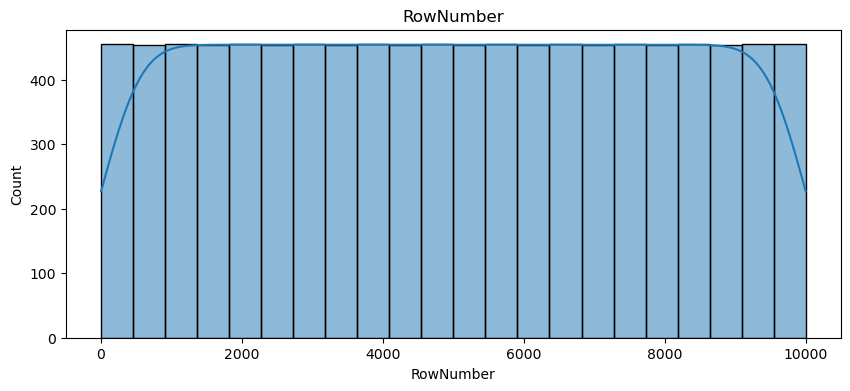

Distribution of : Text(0.5, 1.0, 'CustomerId')


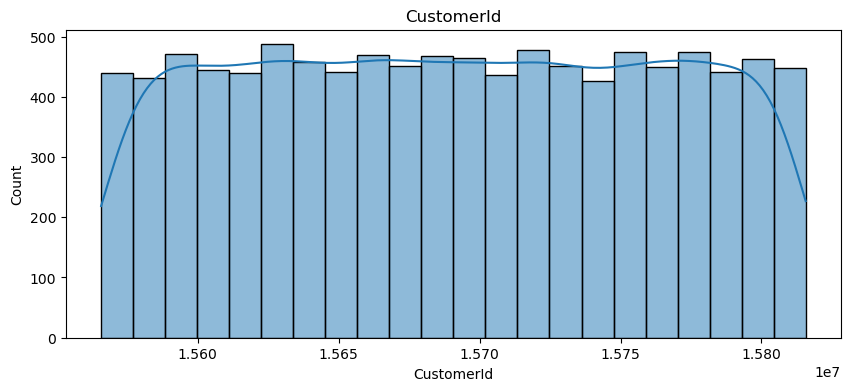

Distribution of : Text(0.5, 1.0, 'Surname')


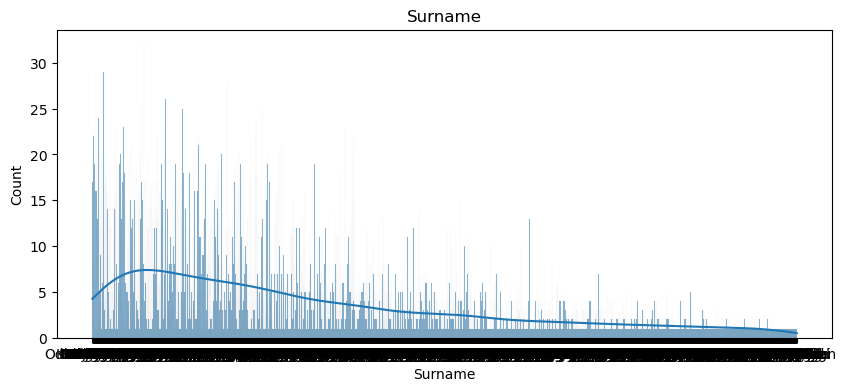

Distribution of : Text(0.5, 1.0, 'CreditScore')


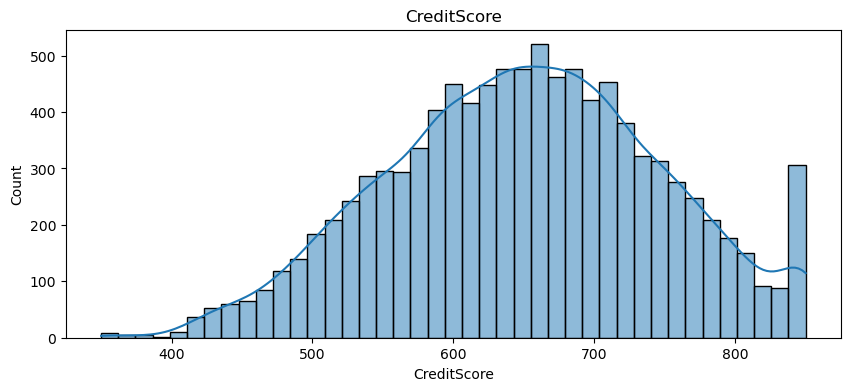

Distribution of : Text(0.5, 1.0, 'Geography')


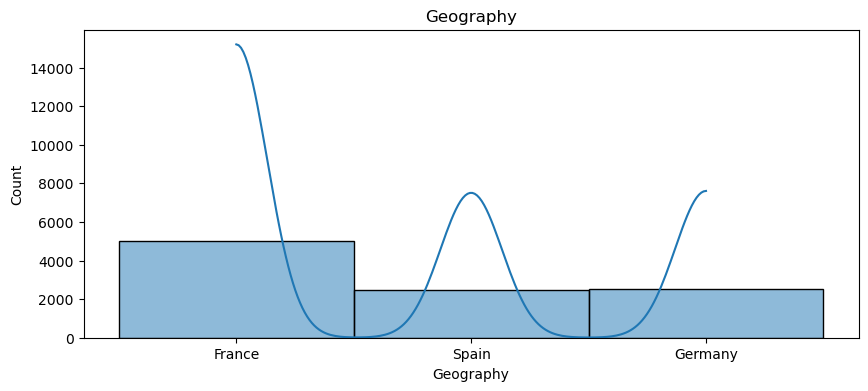

Distribution of : Text(0.5, 1.0, 'Gender')


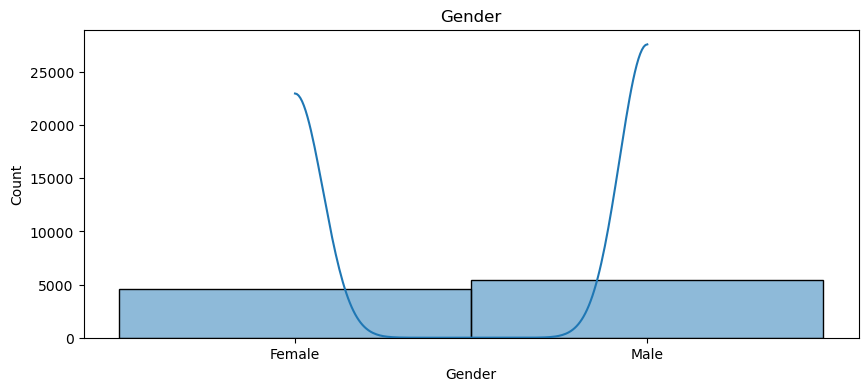

Distribution of : Text(0.5, 1.0, 'Age')


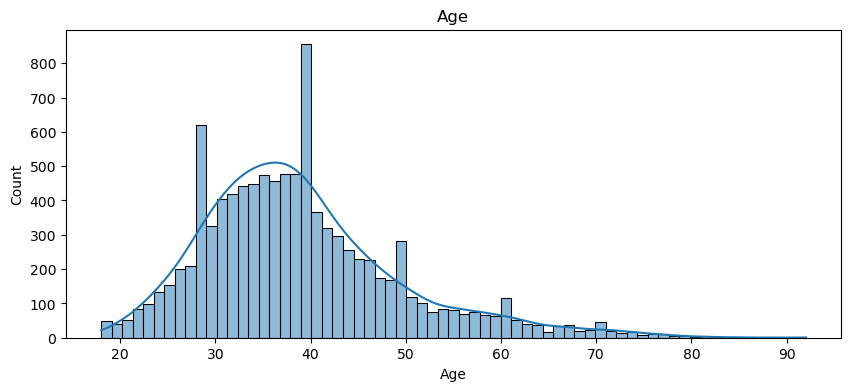

Distribution of : Text(0.5, 1.0, 'Tenure')


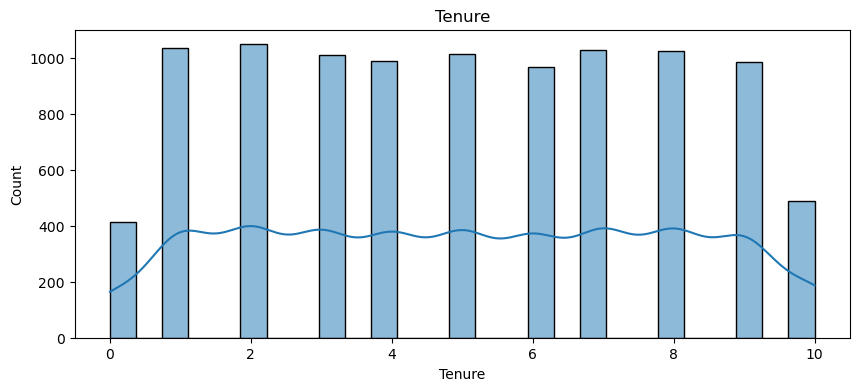

Distribution of : Text(0.5, 1.0, 'Balance')


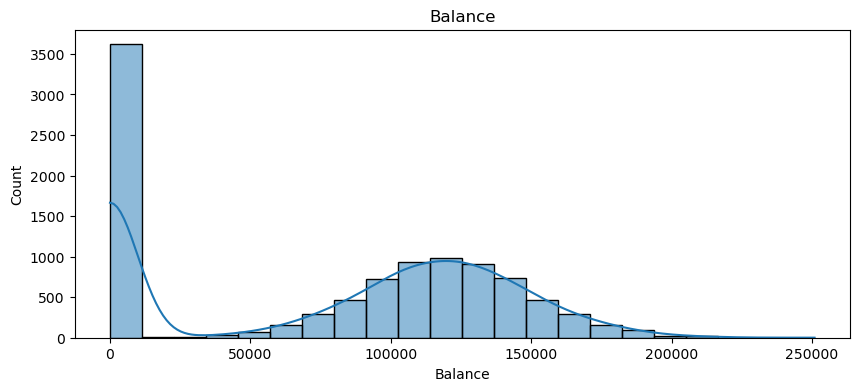

Distribution of : Text(0.5, 1.0, 'NumOfProducts')


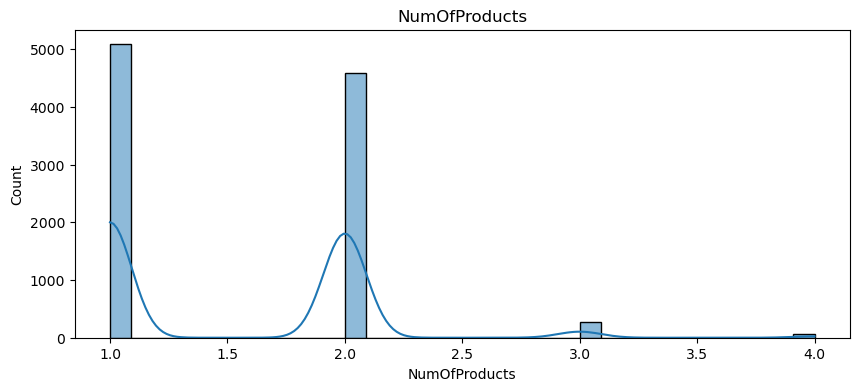

Distribution of : Text(0.5, 1.0, 'HasCrCard')


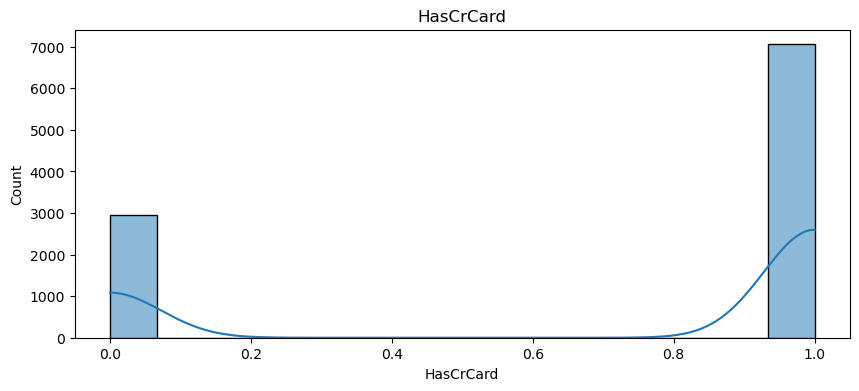

Distribution of : Text(0.5, 1.0, 'IsActiveMember')


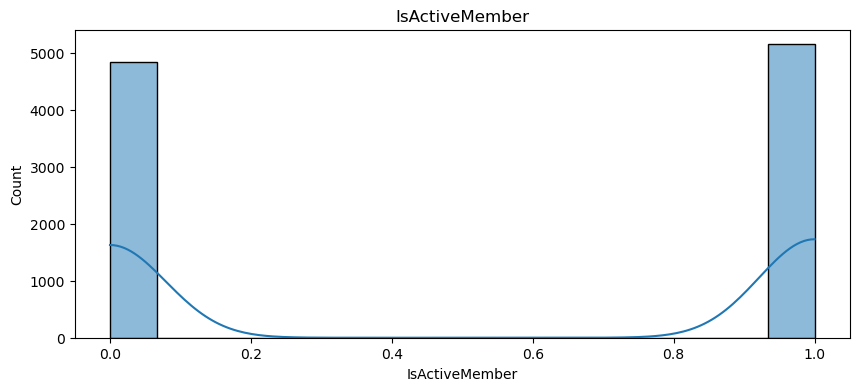

Distribution of : Text(0.5, 1.0, 'EstimatedSalary')


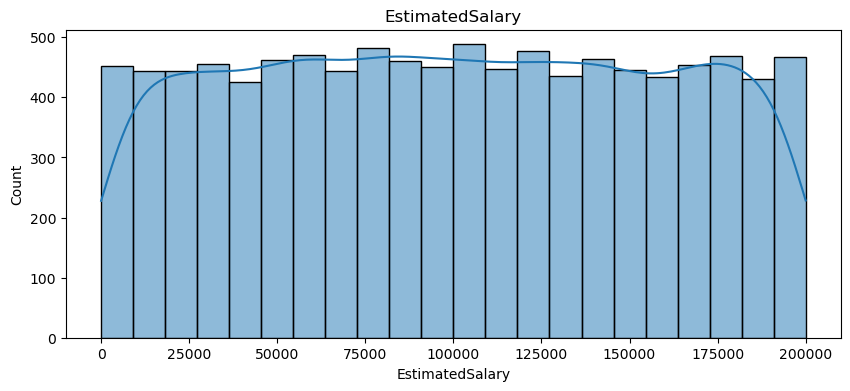

Distribution of : Text(0.5, 1.0, 'Exited')


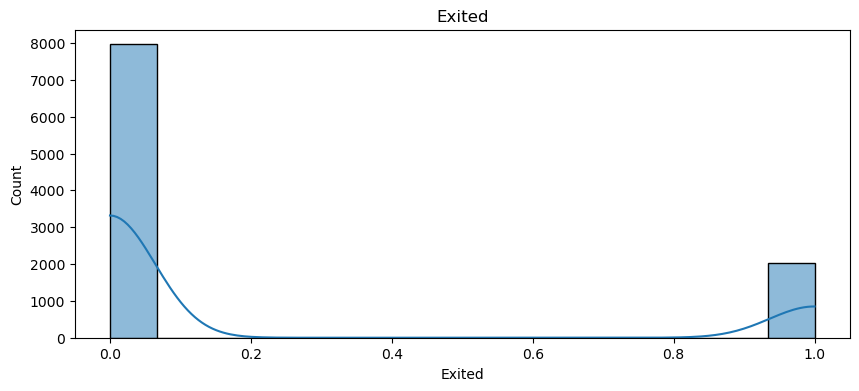

In [15]:
# uni-variate analysis
for col in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df,x=col,kde=True)
    print('Distribution of :',plt.title(col))

# Bi-variate analysis

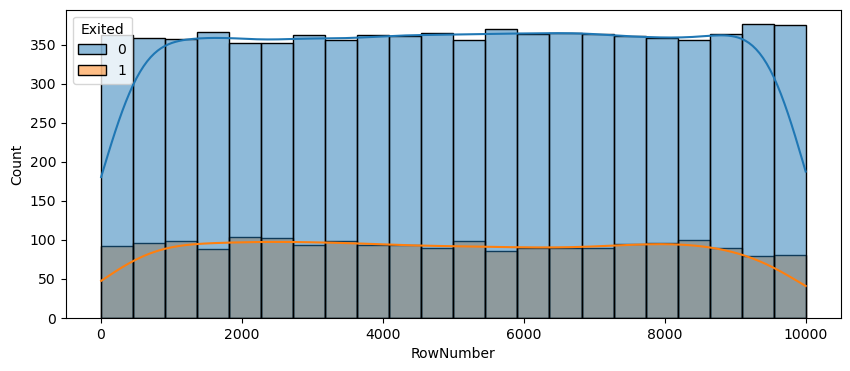

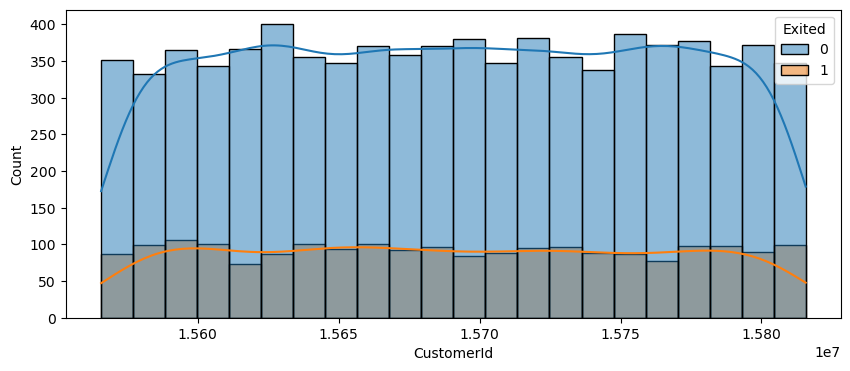

C:\Users\dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


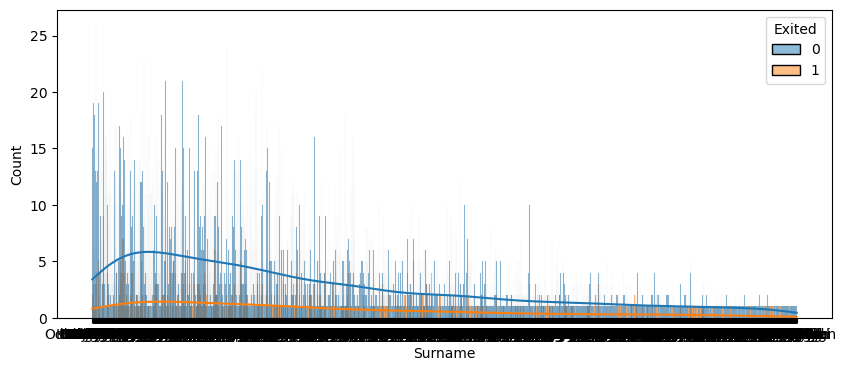

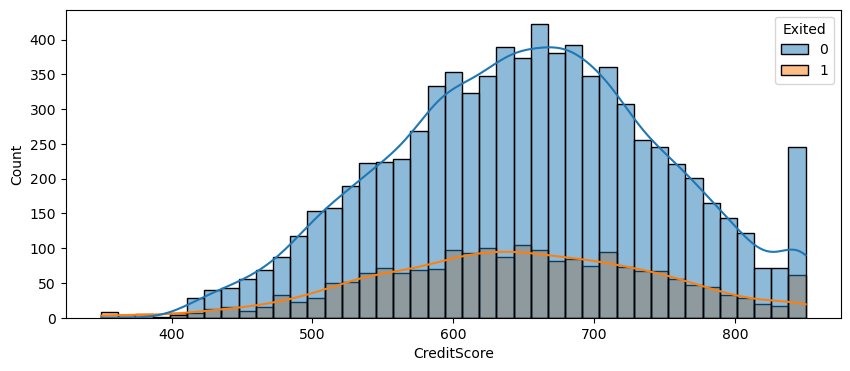

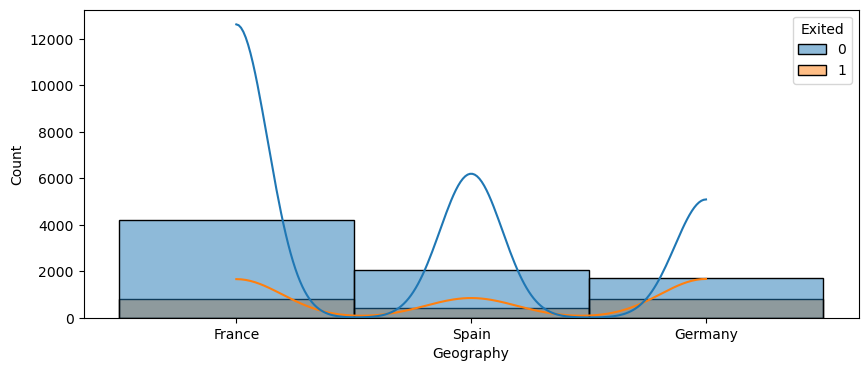

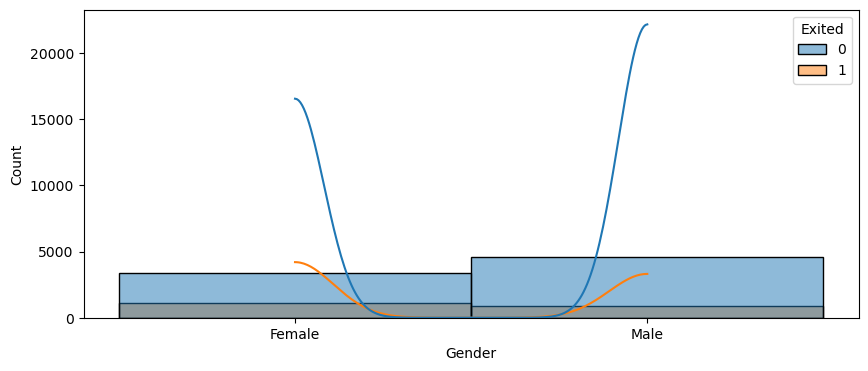

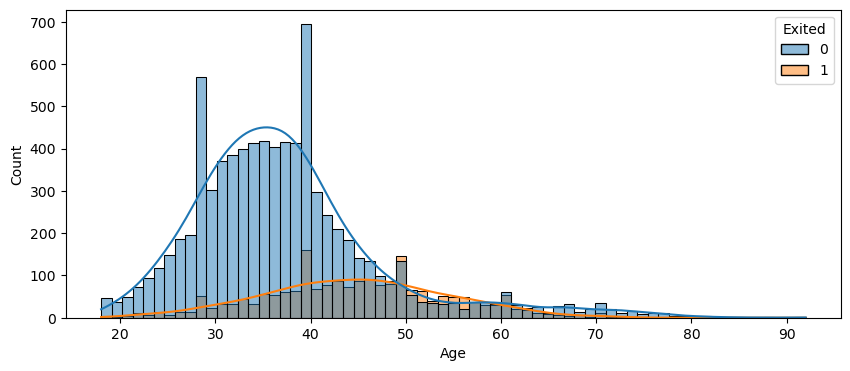

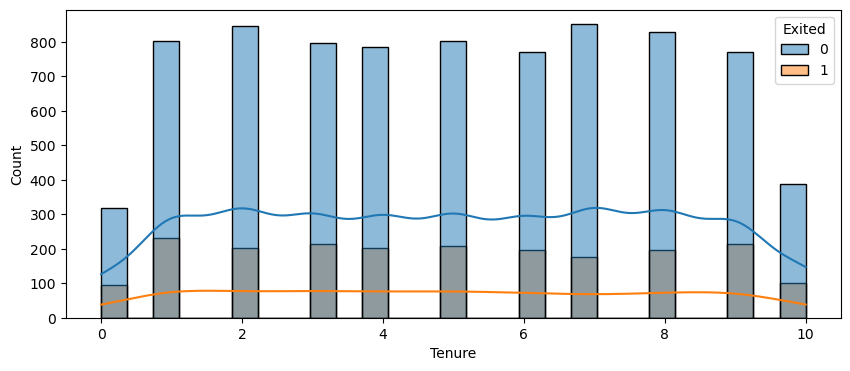

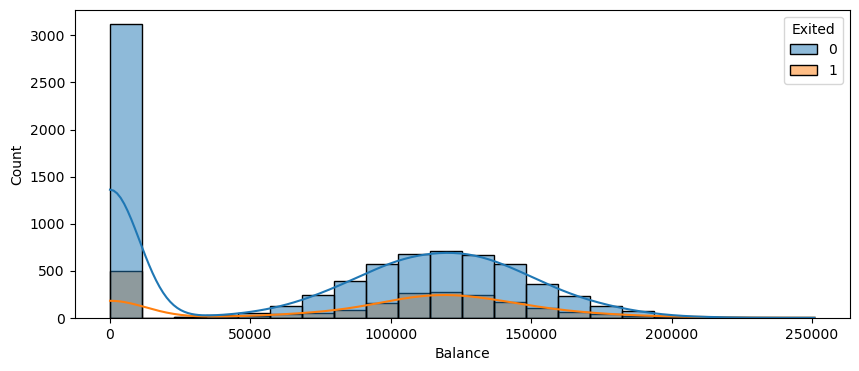

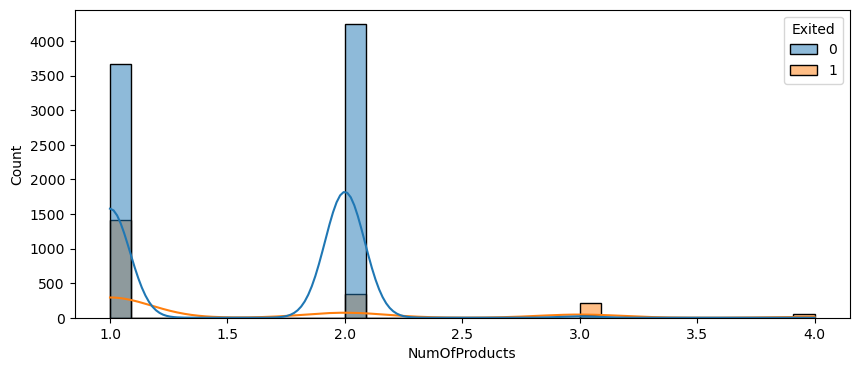

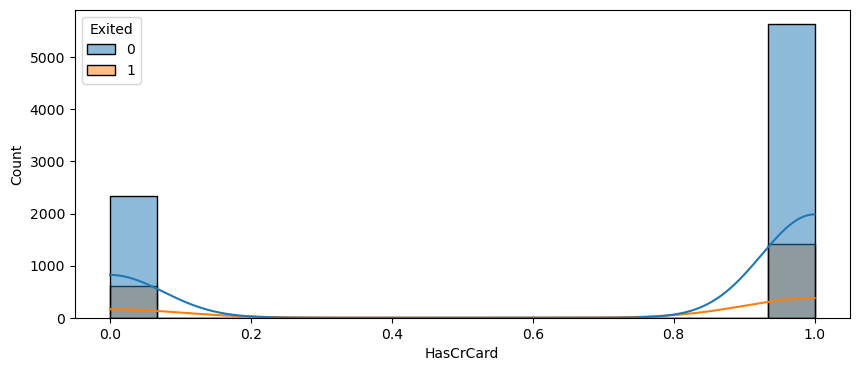

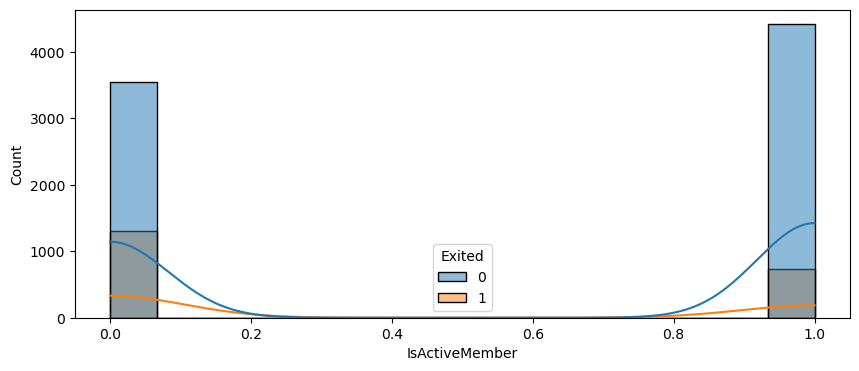

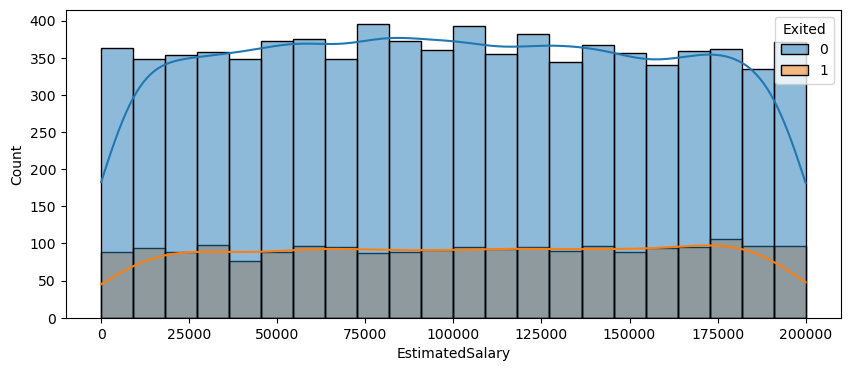

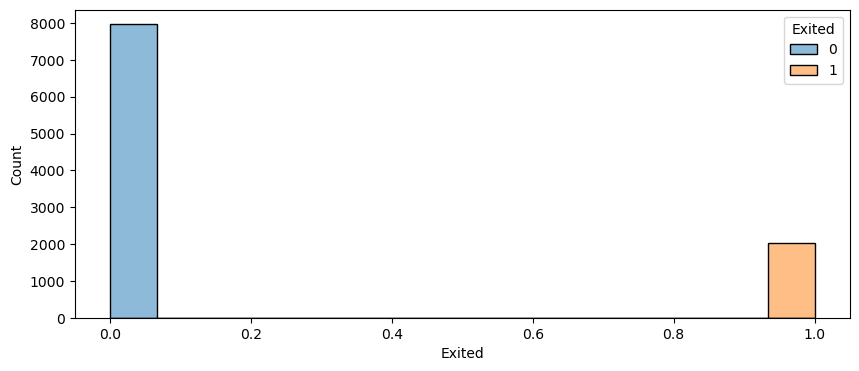

In [18]:
for col in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df,x=col,kde=True,hue='Exited')
    plt.xlabel(col)
    plt.show()

# considering inputs and targets

In [19]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [32]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [33]:
inputs=df.iloc[:,:-1]

In [34]:
targets=df.iloc[:,-1]

In [35]:
inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [36]:
targets.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

## considering the numerical and categorical cols

In [37]:
numerical_cols = inputs.select_dtypes(include=np.number).columns.tolist()

In [38]:
categorical_cols = inputs.select_dtypes(include='object').columns.tolist()

In [39]:
numerical_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [40]:
categorical_cols

['Geography', 'Gender']

In [41]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [43]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [45]:
# Scaling the numerical_cols
from sklearn.preprocessing import MinMaxScaler

In [47]:
scaler = MinMaxScaler().fit(df[numerical_cols])

In [48]:
df[numerical_cols] = scaler.transform(df[numerical_cols])

In [50]:
df[numerical_cols].head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735
1,0.516,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709
2,0.304,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120
4,1.000,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400


In [51]:
## Encoding the Categorical_cols
from sklearn.preprocessing import OneHotEncoder

In [52]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(df[categorical_cols])
encoded_features = encoder.get_feature_names_out(categorical_cols)
print(encoded_features)

['Geography_France' 'Geography_Germany' 'Geography_Spain' 'Gender_Female'
 'Gender_Male']


In [54]:
df[encoded_features] = encoder.transform(df[categorical_cols])

In [55]:
df[encoded_features].head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0


In [58]:
X = pd.concat([df[numerical_cols],df[encoded_features]],axis=1)

In [59]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735,1.0,0.0,0.0,1.0,0.0
1,0.516,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709,0.0,0.0,1.0,1.0,0.0
2,0.304,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654,1.0,0.0,0.0,1.0,0.0
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120,1.0,0.0,0.0,1.0,0.0
4,1.000,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400,0.0,0.0,1.0,1.0,0.0


In [60]:
y=targets

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [65]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((7000, 13), (3000, 13), (7000,), (3000,))

## model prediction and evaluation

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [109]:
model = LogisticRegression().fit(X_train,y_train)

In [110]:
preds = model.predict(X_test)

In [111]:
accuracy_score(y_test,preds)

0.8133333333333334

In [113]:
cf=confusion_matrix(y_test,preds)
cf

array([[2328,   88],
       [ 472,  112]], dtype=int64)

<Axes: >

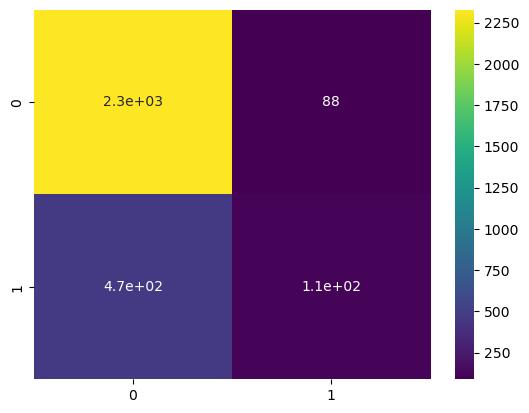

In [81]:
sns.heatmap(cf,cmap='viridis',annot=True)

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [121]:
model = DecisionTreeClassifier(max_depth=5,max_features=None,random_state=42).fit(X_train,y_train)

In [122]:
preds = model.predict(X_test)

In [123]:
accuracy_score(y_test,preds)

0.8623333333333333

In [124]:
cf=confusion_matrix(y_test,preds)
cf

array([[2358,   58],
       [ 355,  229]], dtype=int64)

<Axes: >

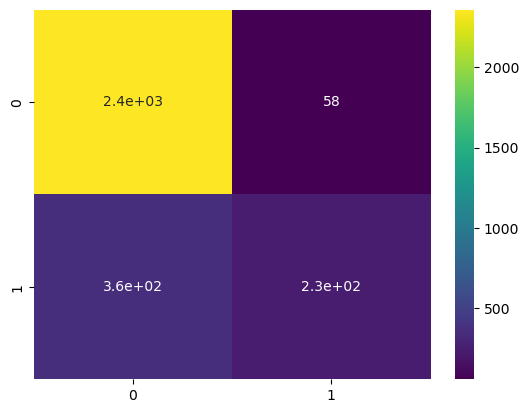

In [125]:
sns.heatmap(cf,cmap='viridis',annot=True)

In [137]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with tuned hyperparameters
model = RandomForestClassifier(
    n_estimators=300,       # number of trees
    max_depth=10,           # limit tree depth to reduce overfitting
    min_samples_split=10,   # minimum samples to split a node
    min_samples_leaf=4,     # minimum samples per leaf
    max_features='sqrt',    # number of features to consider at each split
    criterion='entropy',    # splitting criterion
    class_weight='balanced',# handle class imbalance
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

# Train the model
model.fit(X_train, y_train)

# # Evaluate
# train_acc = model.score(X_train, y_train)
# test_acc = model.score(X_test, y_test)

# print("Training Accuracy:", train_acc)
# print("Test Accuracy:", test_acc)

preds = model.predict(X_test)

In [138]:
accuracy_score(y_test,preds)

0.8396666666666667

In [139]:
cf=confusion_matrix(y_test,preds)
cf

array([[2129,  287],
       [ 194,  390]], dtype=int64)

In [143]:
from xgboost import XGBClassifier

# XGBoost with tuned hyperparameters
model = XGBClassifier(
    n_estimators=500,        # number of trees
    learning_rate=0.05,      # smaller → slower but better convergence
    max_depth=6,             # tree depth
    subsample=0.8,           # use 80% of rows per tree
    colsample_bytree=0.8,    # use 80% of features per tree
    min_child_weight=3,      # min sum of instance weight (controls overfitting)
    gamma=0.1,               # minimum loss reduction for further split
    reg_lambda=1,            # L2 regularization
    reg_alpha=0,             # L1 regularization
    scale_pos_weight=1,      # adjust for imbalance (can tune further)
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# # Evaluate
# train_acc = model.score(X_train, y_train)
# test_acc = model.score(X_test, y_test)

# print("Training Accuracy:", train_acc)
# print("Test Accuracy:", test_acc)
preds = model.predict(X_test)

C:\Users\dell\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:45:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [141]:
accuracy_score(y_test,preds)

0.8663333333333333

In [142]:
cf=confusion_matrix(y_test,preds)
cf

array([[2311,  105],
       [ 296,  288]], dtype=int64)

In [145]:
import tensorflow as tf

In [152]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU,LeakyReLU,PReLU 
from tensorflow.keras.layers import Dropout

In [156]:
X_train.shape

(7000, 13)

In [153]:
classifier = Sequential()

In [157]:
## Input layer
classifier.add(Dense(units=13,activation='relu'))

In [158]:
## 1st Hidden Layer
classifier.add(Dense(units=10,activation='relu'))

In [159]:
## 3nd Hidden Layer
classifier.add(Dense(units=6,activation='relu'))

In [160]:
## Output Layer
classifier.add(Dense(1,activation='sigmoid'))

In [161]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [163]:
model_history = classifier.fit(X_train,y_train,validation_split=0.3,epochs=100,batch_size=100)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8467 - loss: 0.3479 - val_accuracy: 0.8524 - val_loss: 0.3582
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8559 - loss: 0.3463 - val_accuracy: 0.8514 - val_loss: 0.3593
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8556 - loss: 0.3527 - val_accuracy: 0.8538 - val_loss: 0.3573
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8549 - loss: 0.3485 - val_accuracy: 0.8543 - val_loss: 0.3574
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8549 - loss: 0.3421 - val_accuracy: 0.8538 - val_loss: 0.3569
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8575 - loss: 0.3375 - val_accuracy: 0.8548 - val_loss: 0.3578
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8555 - loss: 0.3346 - val_accuracy: 0.8581 - val_loss: 0.3575
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8597 - loss: 0.3426 - val_accuracy: 0.8543 -

### inorder to stop the execution when there is no improvement of the loss and accuracy the `Early stopping` is used

In [168]:
early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001, # play by changing these values
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

<IPython.core.display.Javascript object>

In [169]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,epochs=800,batch_size=10,callbacks=early_stopping)

Epoch 1/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8640 - loss: 0.3189 - val_accuracy: 0.8524 - val_loss: 0.3576
Epoch 2/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8502 - loss: 0.3431 - val_accuracy: 0.8533 - val_loss: 0.3605
Epoch 3/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8636 - loss: 0.3247 - val_accuracy: 0.8503 - val_loss: 0.3586
Epoch 4/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8686 - loss: 0.3219 - val_accuracy: 0.8477 - val_loss: 0.3581
Epoch 5/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8595 - loss: 0.3225 - val_accuracy: 0.8403 - val_loss: 0.3628
Epoch 6/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8594 - loss: 0.3290 - val_accuracy: 0.8486 - val_loss: 0.3648
Epoch 7/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8700 - loss: 0.3187 - val_accuracy: 0.8516 - val_loss: 0.3698
Epoch 8/800
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8646 - loss: 0.3237 - val_accu